In [17]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Carregar os dados
df = pd.read_csv("SuperMarket Analysis.csv")

In [19]:
# Ajustar nomes de colunas (para evitar espaços e facilitar uso)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [20]:
# Converter a coluna de data
df['date'] = pd.to_datetime(df['date'])

In [21]:
# Análise exploratória básica
print("Informações gerais:")
print(df.info())
print("\nResumo estatístico:")
print(df.describe())

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   invoice_id               1000 non-null   object        
 1   branch                   1000 non-null   object        
 2   city                     1000 non-null   object        
 3   customer_type            1000 non-null   object        
 4   gender                   1000 non-null   object        
 5   product_line             1000 non-null   object        
 6   unit_price               1000 non-null   float64       
 7   quantity                 1000 non-null   int64         
 8   tax_5%                   1000 non-null   float64       
 9   sales                    1000 non-null   float64       
 10  date                     1000 non-null   datetime64[ns]
 11  time                     1000 non-null   object        
 12  payment        

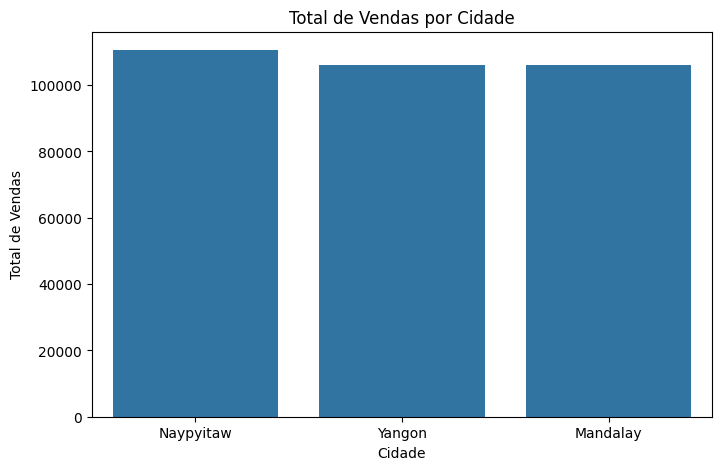

In [22]:
# Vendas por cidade
vendas_por_cidade = df.groupby('city')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=vendas_por_cidade.index, y=vendas_por_cidade.values)
plt.title('Total de Vendas por Cidade')
plt.ylabel('Total de Vendas')
plt.xlabel('Cidade')
plt.show()

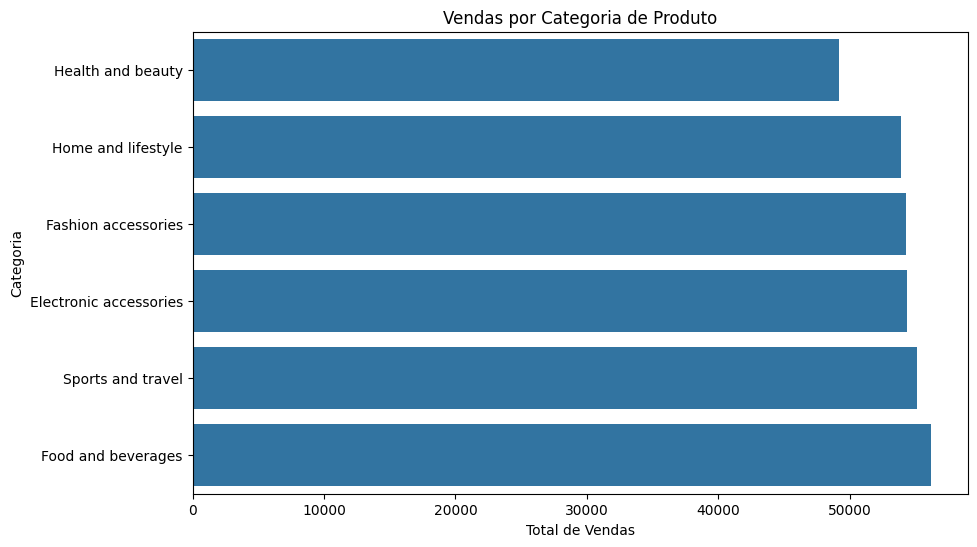

In [23]:
# Produtos mais vendidos
produtos = df.groupby('product_line')['sales'].sum().sort_values()

plt.figure(figsize=(10,6))
sns.barplot(x=produtos.values, y=produtos.index)
plt.title('Vendas por Categoria de Produto')
plt.xlabel('Total de Vendas')
plt.ylabel('Categoria')
plt.show()

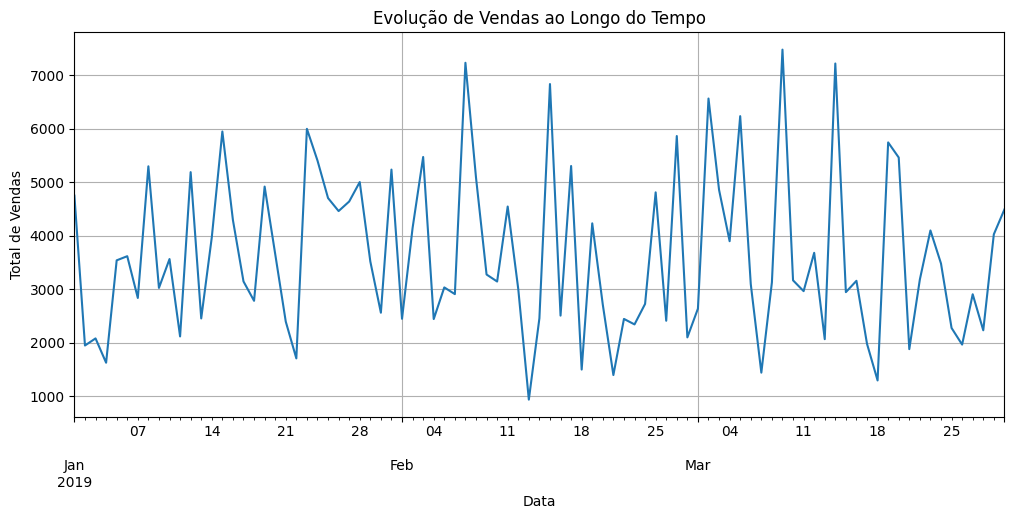

In [24]:
# Evolução de vendas ao longo do tempo
df_por_dia = df.groupby('date')['sales'].sum()

plt.figure(figsize=(12,5))
df_por_dia.plot()
plt.title('Evolução de Vendas ao Longo do Tempo')
plt.ylabel('Total de Vendas')
plt.xlabel('Data')
plt.grid(True)
plt.show()

In [25]:
# Ticket médio
ticket_medio = df['sales'].mean()
print(f"\n🎯 Ticket médio: R${ticket_medio:.2f}")


🎯 Ticket médio: R$322.97


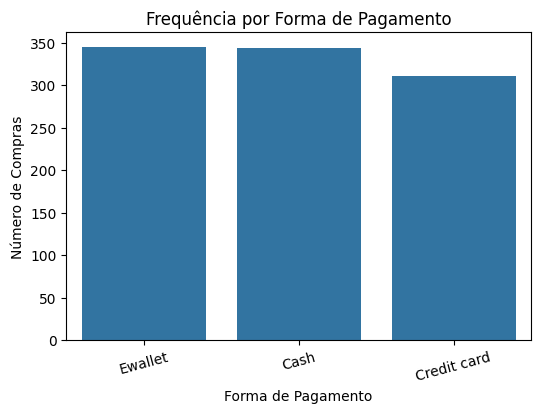

In [26]:
# Forma de pagamento preferida
pagamento = df['payment'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=pagamento.index, y=pagamento.values)
plt.title('Frequência por Forma de Pagamento')
plt.ylabel('Número de Compras')
plt.xlabel('Forma de Pagamento')
plt.xticks(rotation=15)
plt.show()